# Q1: Finding the optimum number of principal components

## Part a : Finding the optimum number of principal components

### Step 1 : Loading data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive


# Load the diabetes dataset
diabetes = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
#diabetes = pd.read_csv('diabetes.csv')

# Quick look at the data
print(diabetes.head())
print(f"Dataset shape: {diabetes.shape}")


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Dataset shape: (768, 9)


### Step 2: Check feature distribution

<Figure size 1200x800 with 0 Axes>

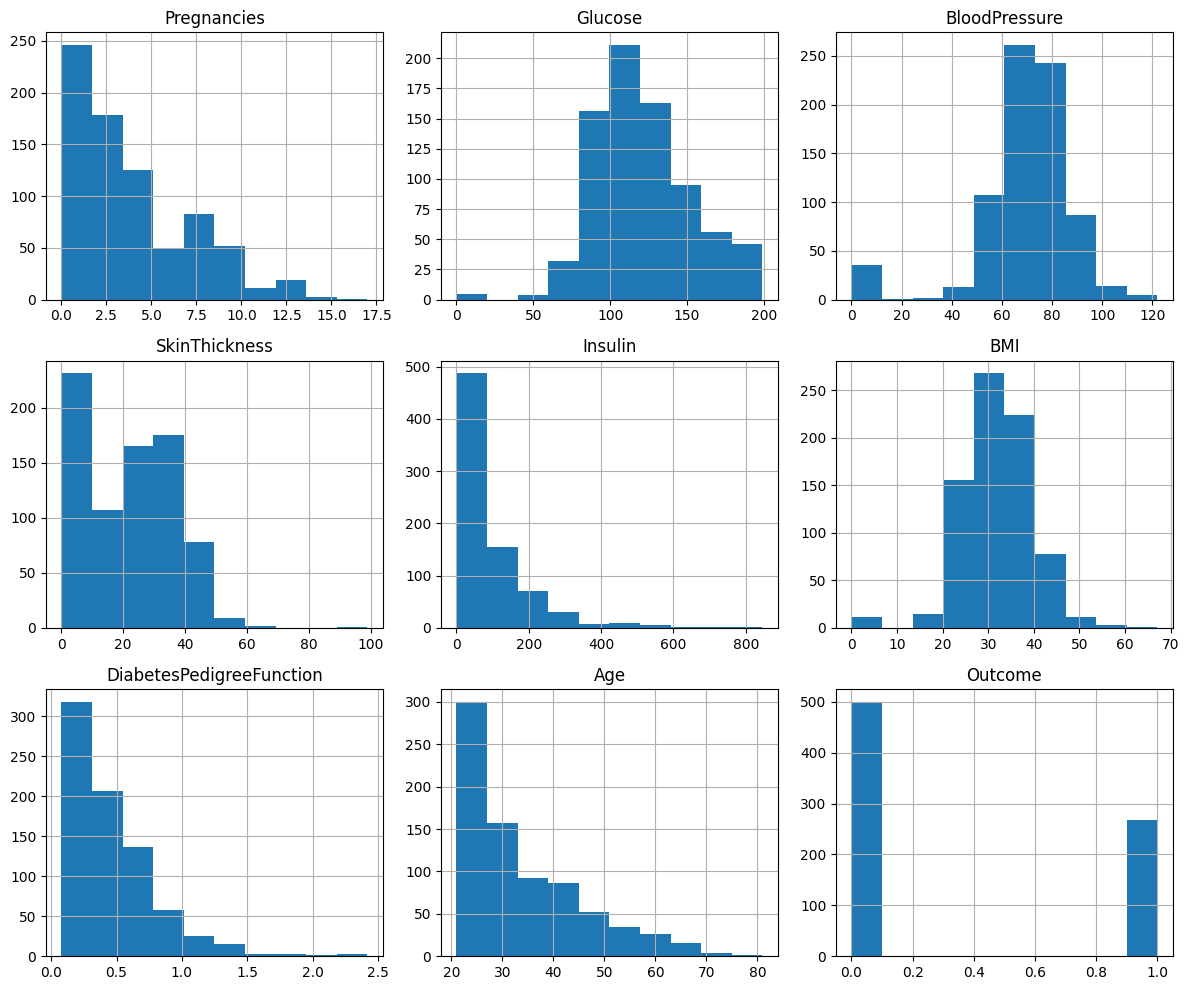

In [ ]:
# Feature distributions
plt.figure(figsize=(12, 8))
diabetes.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


### Step 3: Data Preprocessing and Standardization

In [ ]:
# Prepare features and target
X = diabetes.drop('Outcome', axis=1)
y = diabetes['Outcome']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Step 4: PCA Application and Variance Analysis

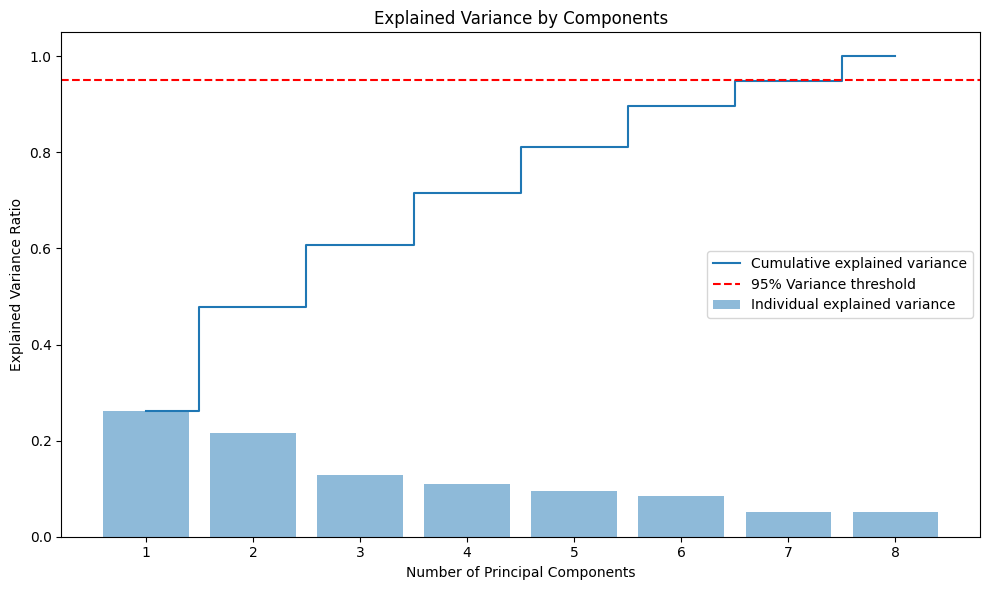

In [ ]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.5,
        label='Individual explained variance')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid',
         label='Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Print the cumulative variance
for i, var in enumerate(cumulative_variance):
    print(f"Components: {i+1}, Cumulative Variance: {var:.4f}")


Components: 1, Cumulative Variance: 0.2618
Components: 2, Cumulative Variance: 0.4782
Components: 3, Cumulative Variance: 0.6069
Components: 4, Cumulative Variance: 0.7163
Components: 5, Cumulative Variance: 0.8116
Components: 6, Cumulative Variance: 0.8970
Components: 7, Cumulative Variance: 0.9494
Components: 8, Cumulative Variance: 1.0000


## Part b: Find the prediction accuracy and error

### Step 1: Split the data

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Step 2: Transform the data

In [ ]:
# Transform data using PCA with optimal components
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

### Step 3: Linear Regression

In [ ]:
# Model 1: Linear Regression on original data
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Model 1: Linear Regression on PCA data
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
mse_lr_pca = mean_squared_error(y_test, y_pred_lr_pca)
r2_lr_pca = r2_score(y_test, y_pred_lr_pca)

### Step 4: Ridge regression

In [ ]:
# Model 2: Ridge Regression on original data
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Model 2: Ridge Regression on PCA data
ridge_pca = Ridge(alpha=1.0)
ridge_pca.fit(X_train_pca, y_train)
y_pred_ridge_pca = ridge_pca.predict(X_test_pca)
mse_ridge_pca = mean_squared_error(y_test, y_pred_ridge_pca)
r2_ridge_pca = r2_score(y_test, y_pred_ridge_pca)

### Step 5: Prepare result data for plotting

In [ ]:
# Prepare results for plotting
models = ['Linear Regression', 'Linear Regression\nwith PCA',
          'Ridge Regression', 'Ridge Regression\nwith PCA']
mse_values = [mse_lr, mse_lr_pca, mse_ridge, mse_ridge_pca]
r2_values = [r2_lr, r2_lr_pca, r2_ridge, r2_ridge_pca]

### Step 6: Plot comparison of results

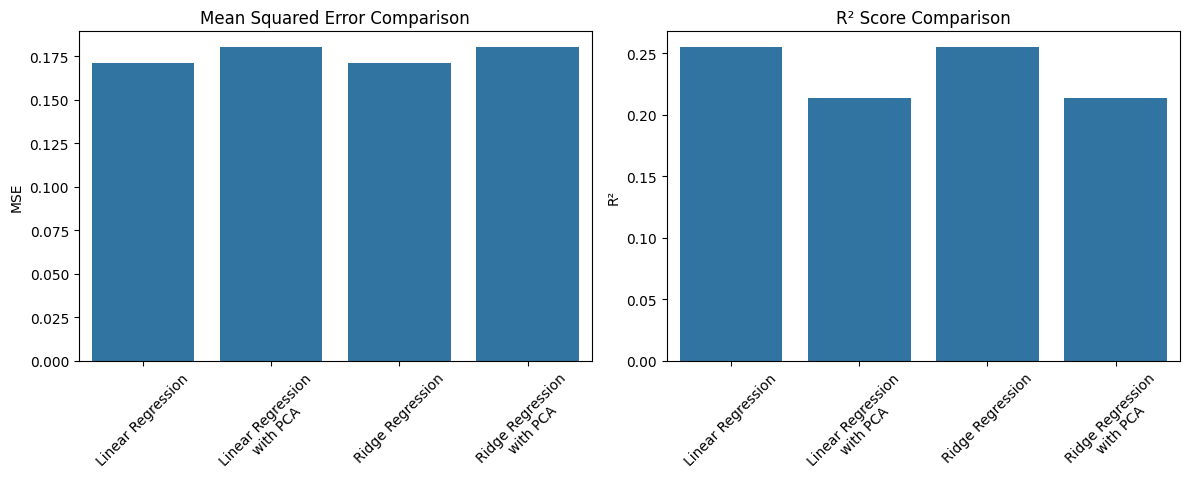

In [ ]:
# Plot MSE comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=models, y=mse_values)
plt.title('Mean Squared Error Comparison')
plt.ylabel('MSE')
plt.xticks(rotation=45)

# Plot R² comparison
plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_values)
plt.title('R² Score Comparison')
plt.ylabel('R²')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Q2: K-means Clustering Analysis on Fashion-MNIST Dataset

## Step 1: Loading and Preprocessing the Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import pandas as pd

# Load the Fashion MNIST dataset
fashion_mnist = fetch_openml(name='Fashion-MNIST', version=1, parser='auto')
X = fashion_mnist.data.astype('float32') / 255.0  # Normalize pixel values
y = fashion_mnist.target.astype('int')

# Print basic information about the dataset
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")


Dataset shape: (70000, 784)
Number of classes: 10
Class distribution: [7000 7000 7000 7000 7000 7000 7000 7000 7000 7000]


### Working with a subset

In [ ]:
# Using a subset for faster computation
X_sample, _, y_sample, _ = train_test_split(X, y, test_size=0.8, random_state=42)
print(f"Working with sample of shape: {X_sample.shape}")

Working with sample of shape: (14000, 784)


### Visualise sample images

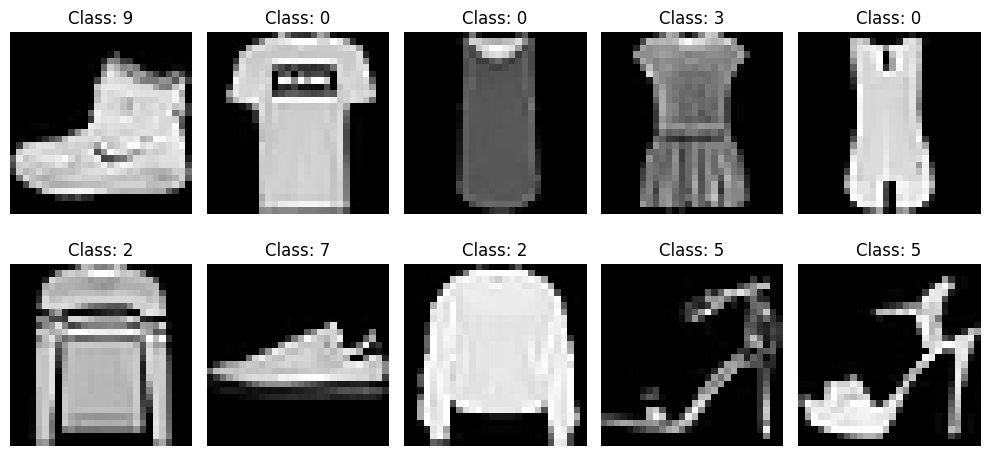

In [ ]:
# Visualize some sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Convert the pandas Series to a NumPy array and then reshape
    plt.imshow(X.iloc[i].values.reshape(28, 28), cmap='gray')
    plt.title(f"Class: {y.iloc[i]}") # Use .iloc to access elements by position
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Training K-means with Random Initializations
Now, We implemented K-means clustering with k=10 (matching the number of classes in the dataset) using random initializations:

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 10 random initial points within the data range
min_vals = X_sample.min(axis=0)
max_vals = X_sample.max(axis=0)
random_init = np.random.uniform(min_vals, max_vals, size=(10, 784))

# Train K-means with random initializations
kmeans_random = KMeans(n_clusters=10, init=random_init, n_init=1, random_state=42)
clusters_random = kmeans_random.fit_predict(X_sample)

# Count the number of points in each cluster
cluster_counts_random = np.bincount(clusters_random)
print("Number of points in each cluster (random initialization):")
for i, count in enumerate(cluster_counts_random):
    print(f"Cluster {i}: {count} points")


Number of points in each cluster (random initialization):
Cluster 0: 1255 points
Cluster 1: 1065 points
Cluster 2: 598 points
Cluster 3: 1967 points
Cluster 4: 1951 points
Cluster 5: 1752 points
Cluster 6: 1220 points
Cluster 7: 503 points
Cluster 8: 1718 points
Cluster 9: 1971 points


## Step 3: Visualizing Cluster Centers as Images
To understand what patterns K-means identified, We visualized the cluster centers as images:

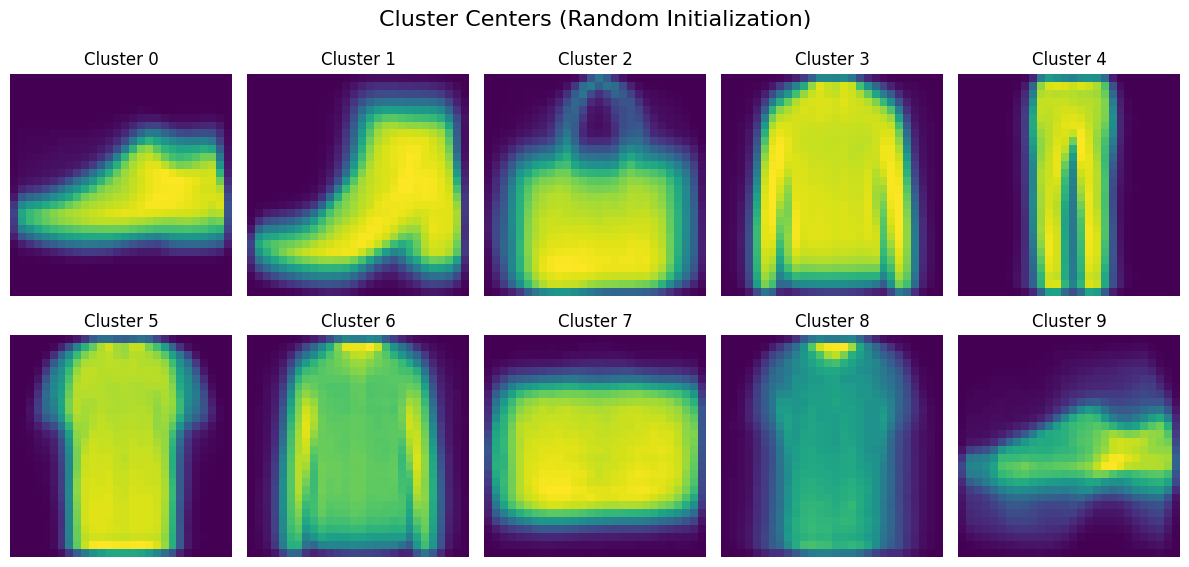

In [ ]:
# Visualize the cluster centers
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(kmeans_random.cluster_centers_[i].reshape(28, 28), cmap='viridis')
    plt.title(f"Cluster {i}")
    plt.axis('off')
plt.suptitle("Cluster Centers (Random Initialization)", fontsize=16)
plt.tight_layout()
plt.show()


## Step 4: Visualizing Sample Images from Each Cluster
Next, we explored the actual images assigned to each cluster:

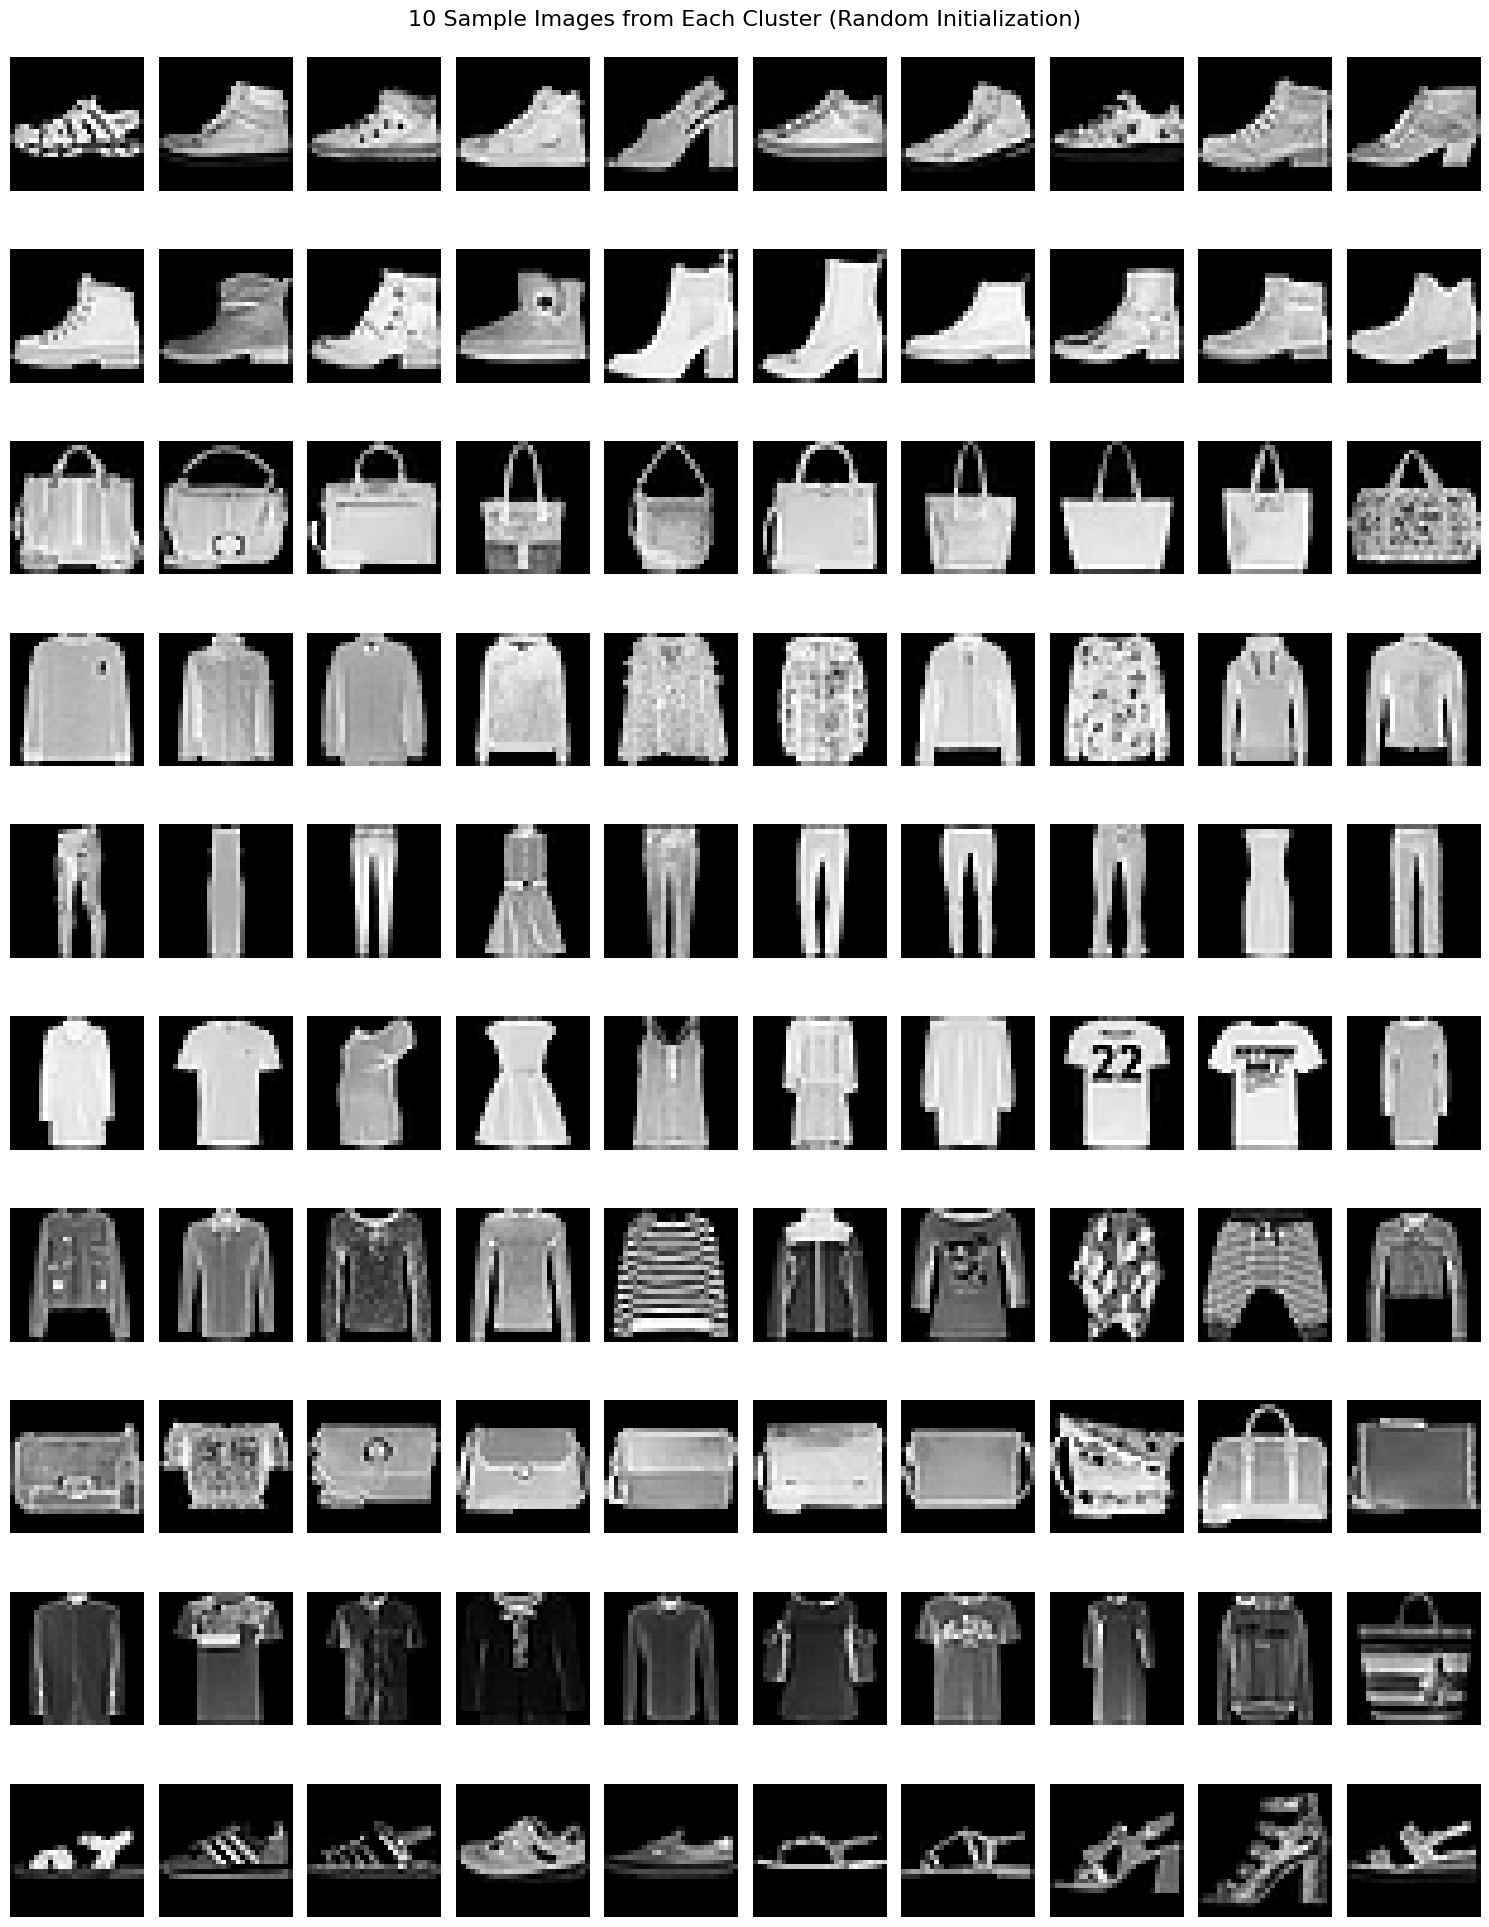

In [ ]:
# Visualize 10 images from each cluster
plt.figure(figsize=(15, 20))
for cluster_idx in range(10):
    cluster_samples = X_sample[clusters_random == cluster_idx]
    for i in range(10):
        if i < len(cluster_samples):
            plt.subplot(10, 10, cluster_idx*10 + i + 1)
            # Access data using .iloc for index-based selection
            plt.imshow(cluster_samples.iloc[i].values.reshape(28, 28), cmap='gray')
            plt.axis('off')
plt.suptitle("10 Sample Images from Each Cluster (Random Initialization)", fontsize=16)
plt.tight_layout()
plt.show()


## Step 5: Training K-means with Class-Based Initializations
For the second approach, We used actual class examples as initial cluster centers:

In [ ]:
# Initialize centers using 10 examples from each class
class_based_init = np.zeros((10, 784))
for class_idx in range(10):
    class_samples = X[y == class_idx]
    # Access the first row's values using .iloc and convert to NumPy array
    class_based_init[class_idx] = class_samples.iloc[0].values

# Train K-means with class-based initializations
kmeans_class = KMeans(n_clusters=10, init=class_based_init, n_init=1, random_state=42)
clusters_class = kmeans_class.fit_predict(X_sample)

# Count the number of points in each cluster
cluster_counts_class = np.bincount(clusters_class)
print("Number of points in each cluster (class-based initialization):")
for i, count in enumerate(cluster_counts_class):
    print(f"Cluster {i}: {count} points")


Number of points in each cluster (class-based initialization):
Cluster 0: 1392 points
Cluster 1: 1196 points
Cluster 2: 2040 points
Cluster 3: 1188 points
Cluster 4: 1823 points
Cluster 5: 1493 points
Cluster 6: 1267 points
Cluster 7: 1679 points
Cluster 8: 645 points
Cluster 9: 1277 points


## Step 6: Visualizing Class-Initialized Cluster Centers

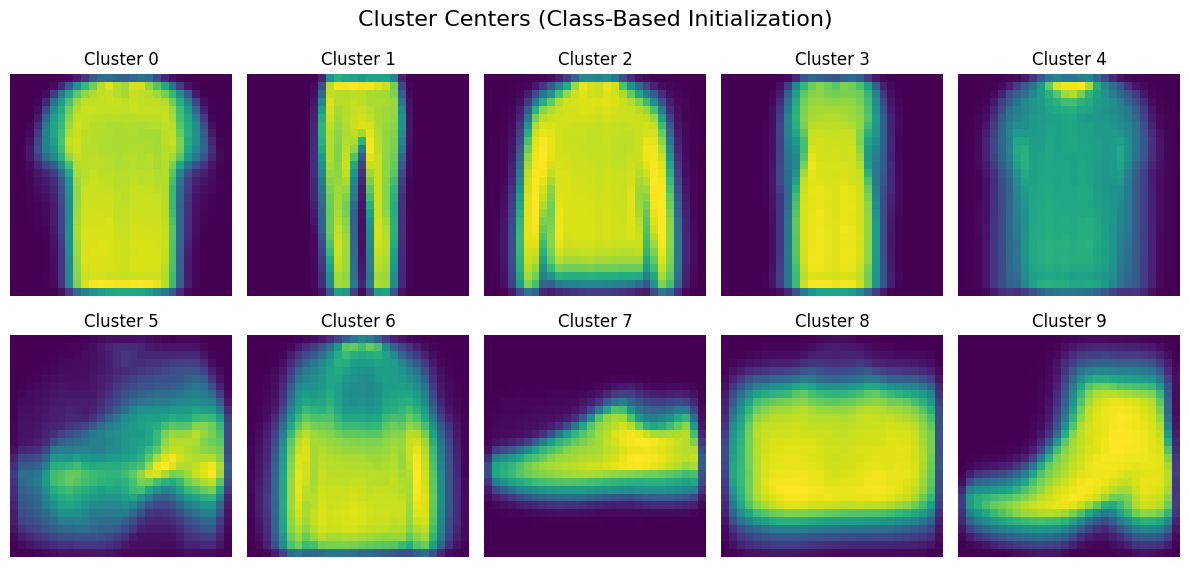

In [ ]:
# Visualize the cluster centers (class-based initialization)
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(kmeans_class.cluster_centers_[i].reshape(28, 28), cmap='viridis')
    plt.title(f"Cluster {i}")
    plt.axis('off')
plt.suptitle("Cluster Centers (Class-Based Initialization)", fontsize=16)
plt.tight_layout()
plt.show()

Step 7: Visualizing Sample Images from Class-Initialized Clusters

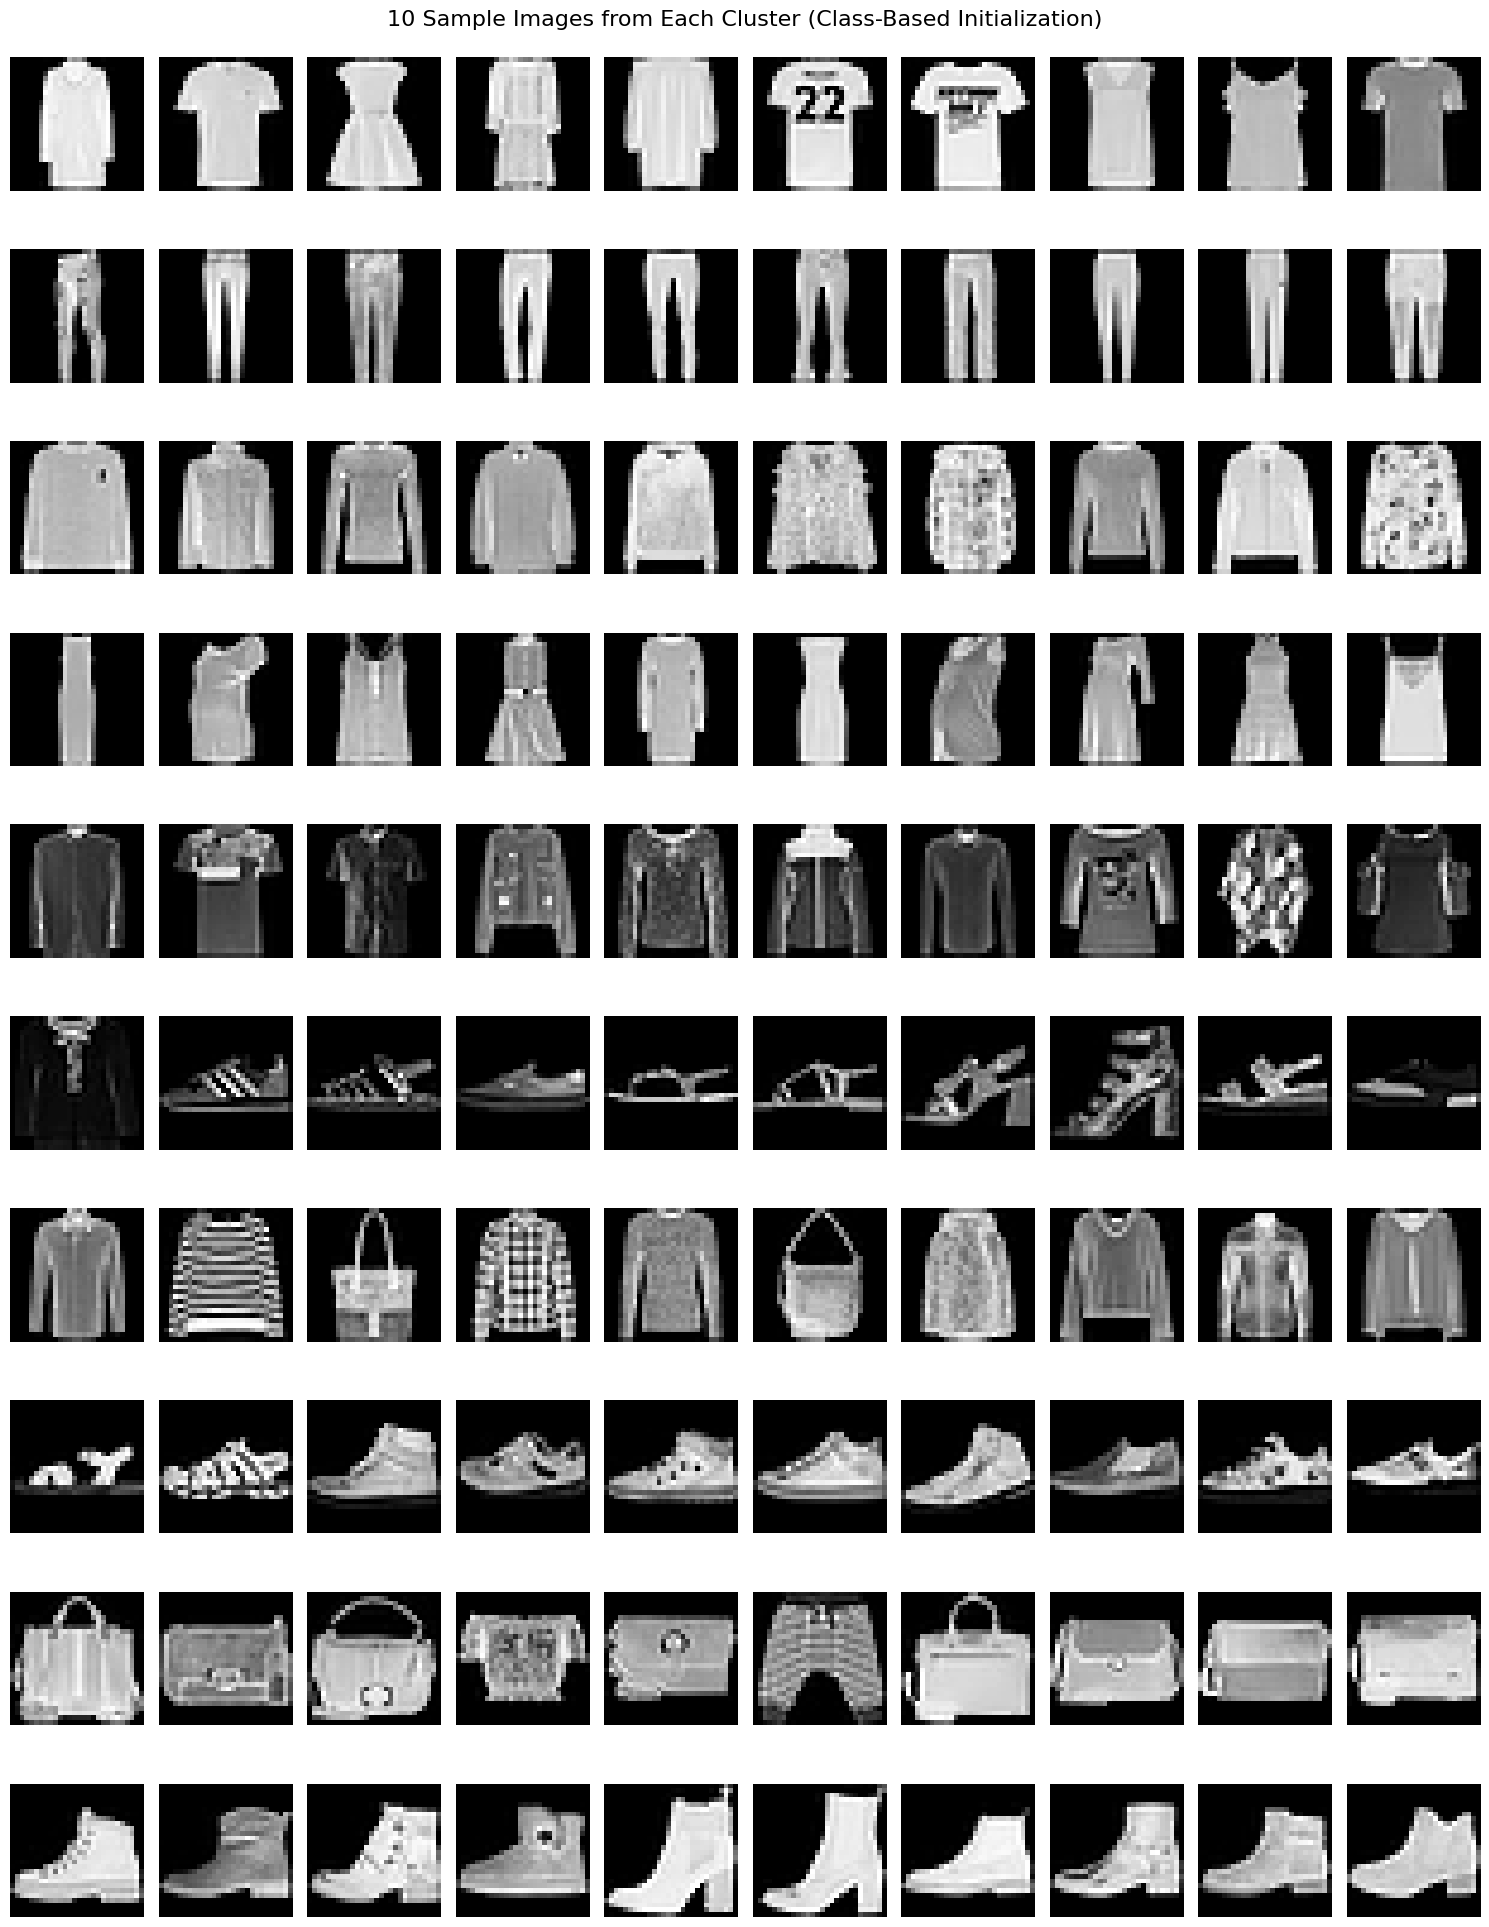

In [ ]:
# Visualize 10 images from each cluster (class-based initialization)
plt.figure(figsize=(15, 20))
for cluster_idx in range(10):
    cluster_samples = X_sample[clusters_class == cluster_idx]
    for i in range(10):
        if i < len(cluster_samples):
            plt.subplot(10, 10, cluster_idx*10 + i + 1)
            # Access data using .iloc for index-based selection
            plt.imshow(cluster_samples.iloc[i].values.reshape(28, 28), cmap='gray') # Use .iloc to access by position
            plt.axis('off')
plt.suptitle("10 Sample Images from Each Cluster (Class-Based Initialization)", fontsize=16)
plt.tight_layout()
plt.show()

## Step 8: Evaluating with Sum of Squared Error (SSE)
To objectively compare the two approaches, I calculated the Sum of Squared Error for both clustering models:

SSE for Random Initialization: 449345.50
SSE for Class-Based Initialization: 450624.73


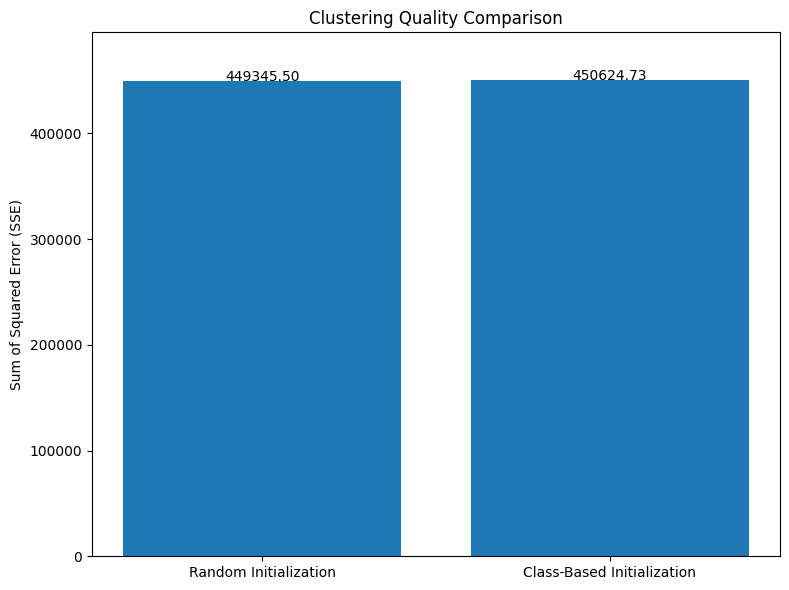

In [ ]:
# Calculate SSE for both models
sse_random = kmeans_random.inertia_
sse_class = kmeans_class.inertia_

print(f"SSE for Random Initialization: {sse_random:.2f}")
print(f"SSE for Class-Based Initialization: {sse_class:.2f}")

# Visualize the SSE comparison
plt.figure(figsize=(8, 6))
plt.bar(['Random Initialization', 'Class-Based Initialization'], [sse_random, sse_class])
plt.ylabel('Sum of Squared Error (SSE)')
plt.title('Clustering Quality Comparison')
plt.ylim(0, max(sse_random, sse_class) * 1.1)
for i, v in enumerate([sse_random, sse_class]):
    plt.text(i, v + 100, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

## Additional Analysis: How Well Do Clusters Match Classes?
We were curious how well the clusters aligned with the original class labels, so we created a confusion matrix:

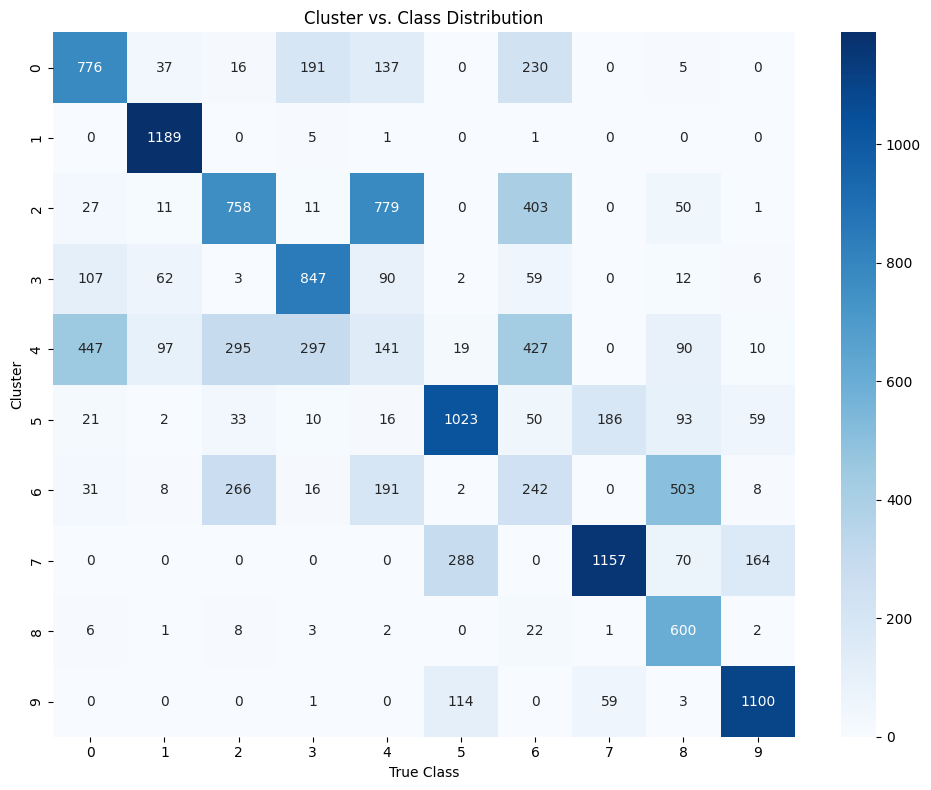

In [ ]:
 # Create a confusion matrix to see how clusters correspond to actual classes
cluster_class_matrix = np.zeros((10, 10), dtype=int)
for i in range(len(y_sample)):
    # Access y_sample using .iloc to ensure positional indexing
    cluster_class_matrix[clusters_class[i], y_sample.iloc[i]] += 1

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cluster_class_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('True Class')
plt.ylabel('Cluster')
plt.title('Cluster vs. Class Distribution')
plt.tight_layout()
plt.show()

For future work, I might experiment with other initialization methods like k-means++ or trydifferent numbers of clusters to see if that improves the results. I might also apply dimensionalityreduction techniques like PCA before clustering to see if they improve the clustering quality byfocusing on the most important features in the data.

#Q3: Implementation of Neural Networks from Scratch Using NumPy and Comparison with Sklearn

For Question 3, We have implemented a neural network both from scratch using NumPy and usingscikit-learn, comparing their performance on the MNIST digits dataset. Here's my step-by-stepapproach:

##Step 1: Loading and Preprocessing the MNIST Digits Dataset
Let's start by loading the MNIST digits dataset and exploring its basic properties:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the MNIST digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Explore the dataset
print(f"Data shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

Data shape: (1797, 64)
Target shape: (1797,)
Number of classes: 10


Let's visualize some sample digits to get a feel for the data:



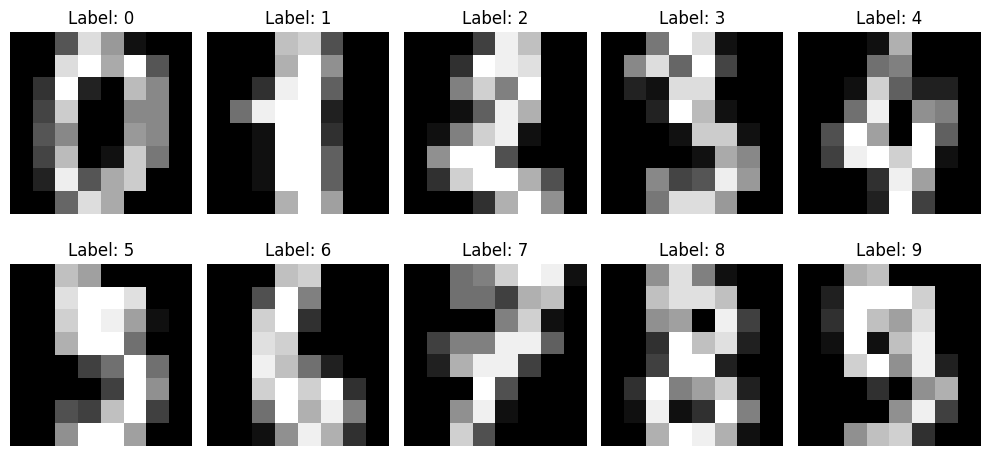

In [ ]:
# Plot some sample digits
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


Now, let's preprocess the data:

In [ ]:
# Scale the features to have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (1257, 64)
Validation set shape: (270, 64)
Test set shape: (270, 64)


In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        # Initialize lists to store training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return self.sigmoid(x) * (1 - self.sigmoid(x))

    def softmax(self, x):
        exp_scores = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    def forward(self, X):
        # Forward pass through the network
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        # Convert y_true to one-hot encoding
        m = y_true.shape[0]
        y_one_hot = np.zeros((m, self.output_size))
        y_one_hot[np.arange(m), y_true] = 1

        # Compute cross-entropy loss
        loss = -np.sum(y_one_hot * np.log(y_pred + 1e-8)) / m
        return loss

    def backward(self, X, y):
        # Convert y to one-hot encoding
        m = y.shape[0]
        y_one_hot = np.zeros((m, self.output_size))
        y_one_hot[np.arange(m), y] = 1

        # Backward pass
        dz2 = self.a2 - y_one_hot
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = np.dot(dz2, self.W2.T) * self.sigmoid_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights and biases
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X_train, y_train, X_val, y_val, epochs):
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X_train)

            # Compute loss
            train_loss = self.compute_loss(y_pred, y_train)

            # Backward pass
            self.backward(X_train, y_train)

            # Compute training accuracy
            train_predictions = np.argmax(y_pred, axis=1)
            train_accuracy = accuracy_score(y_train, train_predictions)

            # Compute validation loss and accuracy
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(val_pred, y_val)
            val_predictions = np.argmax(val_pred, axis=1)
            val_accuracy = accuracy_score(y_val, val_predictions)

            # Store history
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_accuracy)
            self.val_accuracies.append(val_accuracy)

            # Print progress every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)


## Step 3: Training neural network with Hyperparameters

```
# This is formatted as code
```



In [ ]:
# Convert labels to one-hot encoding for training
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

# Function to train the model with different hyperparameters
def train_with_hyperparameters(hidden_sizes, learning_rates, epochs=500):
    results = []

    for hidden_size in hidden_sizes:
        for lr in learning_rates:
            print(f"\nTraining with hidden_size={hidden_size}, learning_rate={lr}")
            model = NeuralNetwork(input_size=64, hidden_size=hidden_size,
                                  output_size=10, learning_rate=lr)
            model.train(X_train, y_train, X_val, y_val, epochs=epochs)

            # Evaluate on validation set
            val_predictions = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, val_predictions)

            results.append({
                'hidden_size': hidden_size,
                'learning_rate': lr,
                'val_accuracy': val_accuracy,
                'model': model
            })

    return results

# Train with different hyperparameters
hidden_sizes = [32, 64, 128]
learning_rates = [0.01, 0.05, 0.1]
results = train_with_hyperparameters(hidden_sizes, learning_rates)

# Find the best model
best_result = max(results, key=lambda x: x['val_accuracy'])
best_model = best_result['model']

print(f"\nBest model: hidden_size={best_result['hidden_size']}, learning_rate={best_result['learning_rate']}, validation accuracy={best_result['val_accuracy']:.4f}")



Training with hidden_size=32, learning_rate=0.01
Epoch 100/500, Train Loss: 2.3015, Train Acc: 0.1042, Val Loss: 2.3078, Val Acc: 0.0667
Epoch 200/500, Train Loss: 2.3005, Train Acc: 0.1161, Val Loss: 2.3088, Val Acc: 0.1000
Epoch 300/500, Train Loss: 2.2996, Train Acc: 0.1050, Val Loss: 2.3087, Val Acc: 0.0963
Epoch 400/500, Train Loss: 2.2984, Train Acc: 0.1050, Val Loss: 2.3080, Val Acc: 0.0963
Epoch 500/500, Train Loss: 2.2970, Train Acc: 0.1050, Val Loss: 2.3068, Val Acc: 0.0963

Training with hidden_size=32, learning_rate=0.05
Epoch 100/500, Train Loss: 2.2971, Train Acc: 0.1050, Val Loss: 2.3066, Val Acc: 0.0963
Epoch 200/500, Train Loss: 2.2796, Train Acc: 0.3302, Val Loss: 2.2899, Val Acc: 0.3148
Epoch 300/500, Train Loss: 2.2073, Train Acc: 0.5593, Val Loss: 2.2191, Val Acc: 0.4963
Epoch 400/500, Train Loss: 2.0066, Train Acc: 0.6221, Val Loss: 2.0223, Val Acc: 0.5556
Epoch 500/500, Train Loss: 1.6996, Train Acc: 0.6786, Val Loss: 1.7190, Val Acc: 0.6481

Training with hidde

## Step 4: Evaluating the Performance on the Testing Set
Now let's evaluate our best model on the test set:

Test accuracy: 0.8852


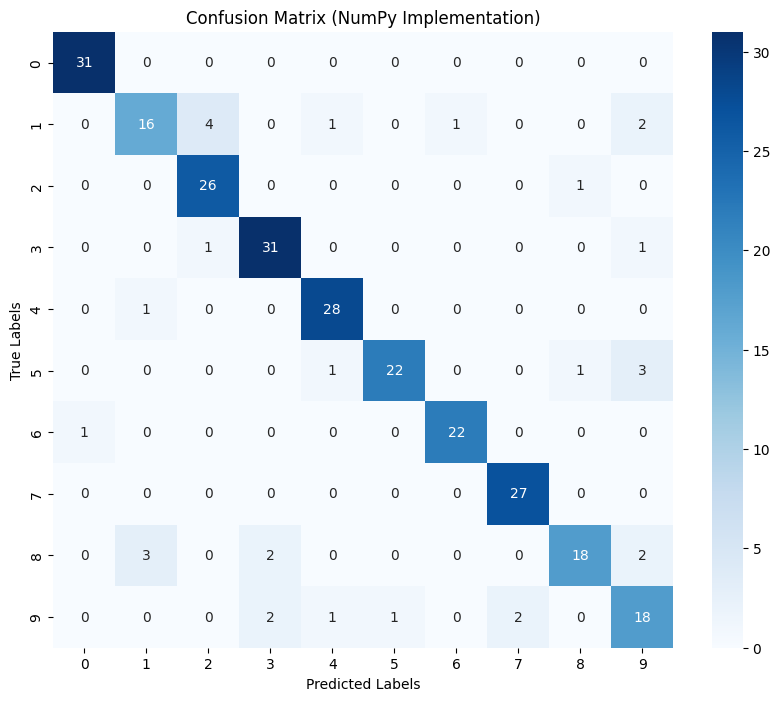

In [ ]:
# Evaluate on test set
test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (NumPy Implementation)')
plt.show()


## Step 5: Implementing the Same Neural Network Using Sklearn


In [ ]:
from sklearn.neural_network import MLPClassifier

# Create model with same architecture as our NumPy implementation
mlp = MLPClassifier(hidden_layer_sizes=(best_result['hidden_size'],),
                    activation='logistic',
                    solver='sgd',
                    learning_rate_init=best_result['learning_rate'],
                    max_iter=500,
                    random_state=42,
                    verbose=True) # Set verbose to True to see training progress

# Train the model
mlp.fit(X_train, y_train)

# Access training loss
train_loss = mlp.loss_
print(f"Training loss: {train_loss:.4f}")

# Evaluate on test set
sklearn_test_predictions = mlp.predict(X_test)
sklearn_test_accuracy = accuracy_score(y_test, sklearn_test_predictions)
print(f"Sklearn model test accuracy: {sklearn_test_accuracy:.4f}")

Iteration 1, loss = 2.23718234
Iteration 2, loss = 1.84003852
Iteration 3, loss = 1.27118053
Iteration 4, loss = 0.80391354
Iteration 5, loss = 0.53121934
Iteration 6, loss = 0.39141596
Iteration 7, loss = 0.30618910
Iteration 8, loss = 0.25343315
Iteration 9, loss = 0.21916607
Iteration 10, loss = 0.19422901
Iteration 11, loss = 0.17466395
Iteration 12, loss = 0.16036989
Iteration 13, loss = 0.14793260
Iteration 14, loss = 0.13713309
Iteration 15, loss = 0.12929101
Iteration 16, loss = 0.12173181
Iteration 17, loss = 0.11479407
Iteration 18, loss = 0.10799709
Iteration 19, loss = 0.10354274
Iteration 20, loss = 0.09837489
Iteration 21, loss = 0.09345514
Iteration 22, loss = 0.08959934
Iteration 23, loss = 0.08560021
Iteration 24, loss = 0.08248202
Iteration 25, loss = 0.08083056
Iteration 26, loss = 0.07622596
Iteration 27, loss = 0.07356863
Iteration 28, loss = 0.07039556
Iteration 29, loss = 0.06824420
Iteration 30, loss = 0.06607462
Iteration 31, loss = 0.06383462
Iteration 32, los

## Step 6: Plotting Training and Validation Loss/Accuracy Curves
Let's visualize the learning curves for both implementations:

Epoch 100, Train Accuracy: 1.0000, Validation Accuracy: 0.9741


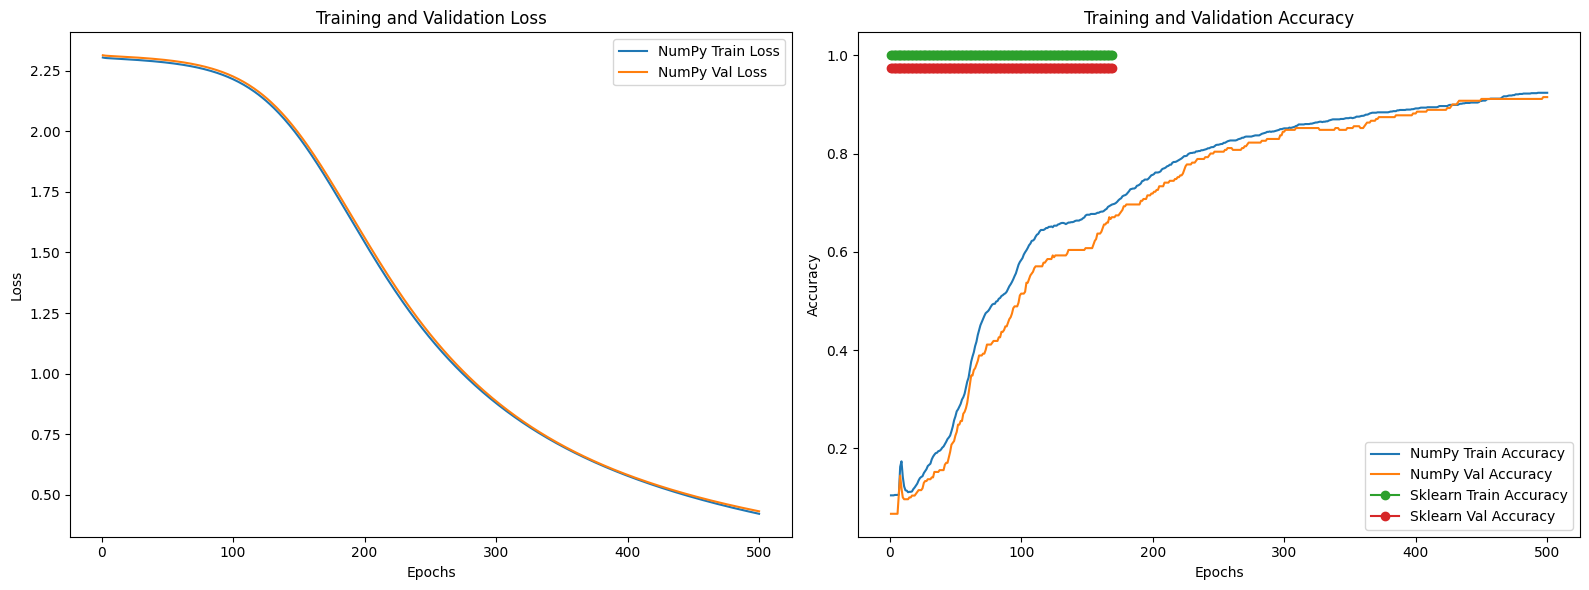

In [ ]:
# Plot learning curves
plt.figure(figsize=(16, 6))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(range(1, len(best_model.train_losses) + 1), best_model.train_losses, label='NumPy Train Loss')
plt.plot(range(1, len(best_model.val_losses) + 1), best_model.val_losses, label='NumPy Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(range(1, len(best_model.train_accuracies) + 1), best_model.train_accuracies, label='NumPy Train Accuracy')
plt.plot(range(1, len(best_model.val_accuracies) + 1), best_model.val_accuracies, label='NumPy Val Accuracy')

# Store training and validation accuracy for Sklearn model
train_accuracies_sklearn = []
val_accuracies_sklearn = []
for i in range(mlp.n_iter_):  # Assuming mlp is your Sklearn model
    # Evaluate on training set
    train_predictions = mlp.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_accuracies_sklearn.append(train_accuracy)

    # Evaluate on validation set
    val_predictions = mlp.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)
    val_accuracies_sklearn.append(val_accuracy)

    if (i + 1) % 100 == 0:  # Log progress for every 100 epochs
        print(f"Epoch {i + 1}, Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")

plt.plot(range(1, mlp.n_iter_ + 1), train_accuracies_sklearn, 'o-', label='Sklearn Train Accuracy') # Adjust for actual epochs
plt.plot(range(1, mlp.n_iter_ + 1), val_accuracies_sklearn, 'o-', label='Sklearn Val Accuracy') # Adjust for actual epochs
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Comparing NumPy and Sklearn Implementations
Finally, let's compare the two implementations:

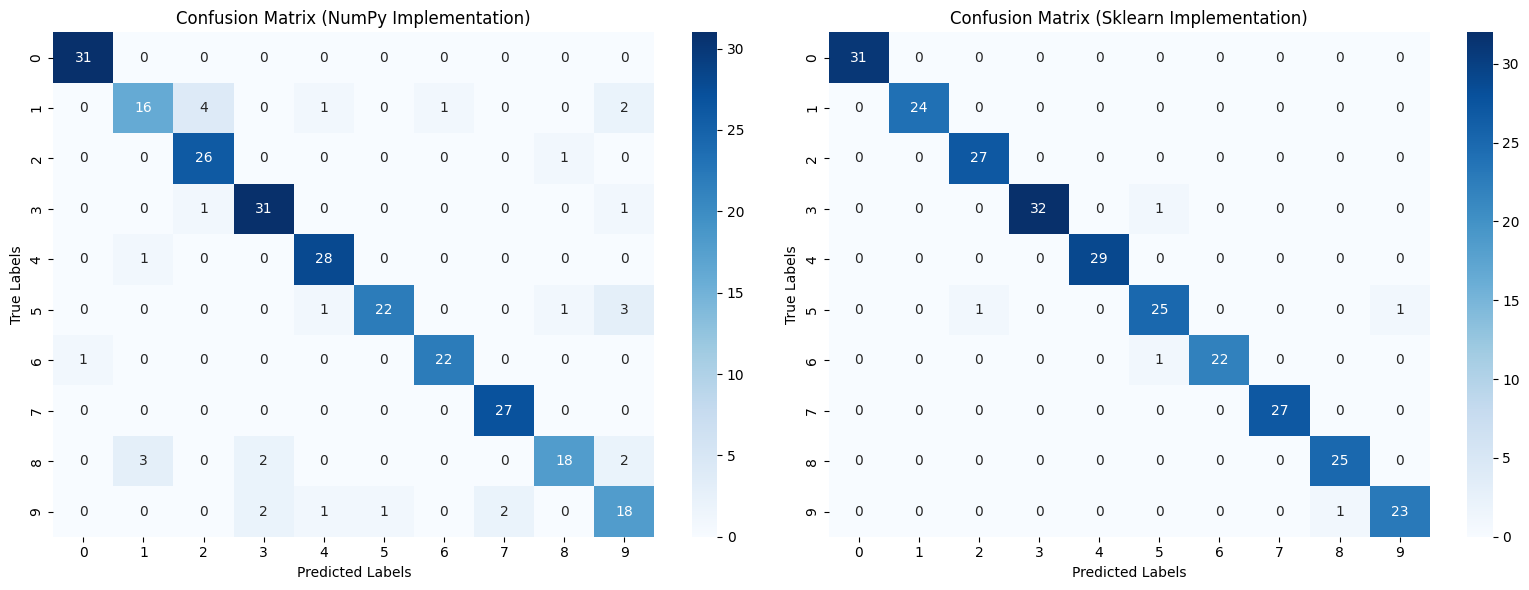


Comparison Summary:
NumPy Implementation Test Accuracy: 0.8852
Sklearn Implementation Test Accuracy: 0.9815
Difference: 0.0963


In [ ]:
# Compare confusion matrices
plt.figure(figsize=(16, 6))

# NumPy confusion matrix
plt.subplot(1, 2, 1)
cm_numpy = confusion_matrix(y_test, test_predictions)
sns.heatmap(cm_numpy, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (NumPy Implementation)')

# Sklearn confusion matrix
plt.subplot(1, 2, 2)
cm_sklearn = confusion_matrix(y_test, sklearn_test_predictions)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Sklearn Implementation)')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\nComparison Summary:")
print(f"NumPy Implementation Test Accuracy: {test_accuracy:.4f}")
print(f"Sklearn Implementation Test Accuracy: {sklearn_test_accuracy:.4f}")
print(f"Difference: {abs(test_accuracy - sklearn_test_accuracy):.4f}")
